In [124]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import datetime
from numpy import trapezoid


# January 2026
TempArrayJan = pd.read_csv('TempJanuary2026.csv')
TempJanAvg = TempArrayJan['Column 3']
TempJanMin = TempArrayJan['Column 2']
TempJanMax = TempArrayJan['Column 1']

MaximumJan = pd.to_numeric(TempJanMax)
numpy_maxJan = MaximumJan[0:-2]

MinimumJan = pd.to_numeric(TempJanMin)
numpy_minJan = MinimumJan[0:-2]

AverageJan = pd.to_numeric(TempJanAvg)
numpy_avgJan = AverageJan[0:-2]

# print(numpy_avgJan)
# print(np.sum(numpy_avgJan))
# print(type(numpy_avgJan[3]))

dayJan = np.linspace(0,31,31)
# plt.plot(dayJan, numpy_avgJan)
# plt.show()


# December 2025
TempArrayDec = pd.read_csv('TempDecember2025.csv')
TempDecAvg = TempArrayDec['Column 3']
TempDecMin = TempArrayDec['Column 2']
TempDecMax = TempArrayDec['Column 1']

MaximumDec = pd.to_numeric(TempDecMax)
numpy_maxDec = MaximumDec[0:-2]

MinimumDec = pd.to_numeric(TempDecMin)
numpy_minDec = MinimumDec[0:-2]

AverageDec = pd.to_numeric(TempDecAvg)
numpy_avgDec = AverageDec[0:-2]

# print(numpy_avgDec)
# print(np.sum(numpy_avgDec))
# print(type(numpy_avgDec[3]))

dayDec = np.linspace(0,31,31)
# plt.plot(dayDec, numpy_avgDec)
# plt.show()


# November 2024
TempArrayNov = pd.read_csv('TempNovember2025.csv')
TempNovAvg = TempArrayNov['Column 3']
TempNovMin = TempArrayNov['Column 2']
TempNovMax = TempArrayNov['Column 1']
# print(len(TempNovMin))
# print(len(TempNovMax))
# print(len(TempNovAvg))

MaximumNov = pd.to_numeric(TempNovMax)
numpy_maxNov = MaximumNov[0:-2]

MinimumNov = pd.to_numeric(TempNovMin)
numpy_minNov = MinimumNov[0:-2]

AverageNov = pd.to_numeric(TempNovAvg)
numpy_avgNov = AverageNov[0:-2]


dayNov = np.linspace(0,30,30)
# plt.plot(dayNov, numpy_avgNov)
# plt.show()




NovDecJanAvg = np.concatenate([numpy_avgNov, numpy_avgDec, numpy_avgJan], axis = 0)
# print(NovDecJanAvg)
# print(len(NovDecJanAvg))
NovDecJanMin = np.concatenate([numpy_minNov,numpy_minDec,numpy_minJan], axis = 0)
NovDecJanMax = np.concatenate([numpy_maxNov,numpy_maxDec,numpy_maxJan], axis = 0)



In [125]:
# Source - https://stackoverflow.com/q/53423072
# Posted by will27272, modified by community. See post 'Timeline' for change history
# Retrieved 2026-03-24, License - CC BY-SA 4.0

def daterange(startdate, enddate):
    r = (enddate+datetime.timedelta(days=1)-startdate).days
    return [startdate+datetime.timedelta(days=i) for i in range(r)]


startdate = datetime.date(2025, 11, 1)
enddate = datetime.date(2026,1,31)
datelist = daterange(startdate, enddate)

FullDateRange = [str(date) for date in datelist]
print(len(FullDateRange))

92


92


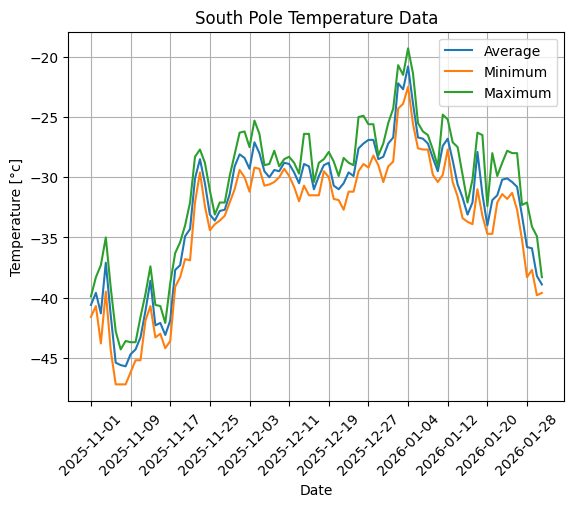

In [126]:
# FullDayRange = np.concat((np.arange(365-31-30+1, 366, 1),np.arange(1,31+1,1)))
# print(FullDayRange)
# print(len(FullDayRange))

print(len(NovDecJanAvg))

plt.plot(FullDateRange, NovDecJanAvg, label = 'Average')
plt.plot(FullDateRange, NovDecJanMin, label = 'Minimum')
plt.plot(FullDateRange, NovDecJanMax, label = 'Maximum')
plt.legend()
plt.xticks(range(0, len(FullDateRange), 8), FullDateRange[::8]) # makes the x axis less crowded
plt.xticks(rotation=45)
plt.xlabel('Date')
plt.ylabel('Temperature [°c]')
plt.title('South Pole Temperature Data')
plt.grid('on')
plt.show()

In [165]:
# now get total energy for each day
from datetime import datetime, timedelta

def date2num(date_str): # Renamed 'date' to 'date_str' to avoid confusion with the datetime.date object
    # 26 # first conver the xxxx-xx-xx format to date(xxxx, xx, xx)

    # You can skip splitting the string and go directly to parsing:
    date_object = datetime.strptime(date_str, '%Y-%m-%d').date()
    
    # 29 # return the day of the year (%j) as an integer
    # The strftime method returns a string, so we convert it to an integer.
    return int(date_object.strftime('%j'))
def num2date(day_num, year):
    """
    Converts a day number (1 to 365/366) and year into a date object.

    Args:
        day_num (int): The day number of the year (1-indexed).
        year (int): The year.

    Returns:
        datetime.date: The corresponding date object.
    """
    # Start date is January 1st of the given year
    start_date = datetime(int(year), 1, 1)
    
    # Calculate the offset (day_num - 1 because the start date is day 1)
    offset = timedelta(days=int(day_num) - 1)
    
    # Add the offset to the start date
    result_date = start_date + offset
    
    return result_date




def LoadPowerData(year, StartDay, EndDay):
    day_range_num =  np.arange(StartDay, EndDay + 1)
    day_range = ['{0:03d}'.format(i) for i in day_range_num]
    # print(day_range)
        
    all_data_101 = []
    all_data_103 = []
    for i in day_range:
        try:
            file101 = pd.read_csv(f"../DataFolder/spo_dev101_{year}_{i}.csv")
            file103 = pd.read_csv(f"../DataFolder/spo_dev103_{year}_{i}.csv")
        except FileNotFoundError:
            print(f"File for day {i} not found. Skipping this day.")
            all_data_101.append(np.nan)
            all_data_103.append(np.nan) 
            continue
        file101.rename(columns = {'Device ID': 'V', 'Voltage': 'A'}, inplace=True)
        file103.rename(columns = {'Device ID': 'V', 'Voltage': 'A'}, inplace=True)
        # print(file101.columns.tolist())
        # print(file101)
    
        # ----------------Gemini code to stop the 'Date' key error--------------------
        # Force-strip whitespace and clean any hidden characters from all columns
        file101.columns = [c.strip().encode('ascii', 'ignore').decode('ascii') for c in file101.columns]
        
        # If that still fails, manually set the first column to 'Date' by position
        file101.rename(columns={file101.columns[0]: 'Date'}, inplace=True)
        file101.rename(columns={file101.columns[2]: 'V'}, inplace=True)
        file101.rename(columns={file101.columns[3]: 'A'}, inplace=True)
        
        
        
        # Now it should be safe
        # ----------------------------------------------------------------------------
        
        date_101 = file101['Date']
        NumberDate = date_101.apply(date2num)
        mask_to_keep =  NumberDate <= int(i)
        file101 = file101[mask_to_keep]
    
        date_103 = file103['Date']
        NumberDate = date_103.apply(date2num)
        mask_to_keep = NumberDate <= int(i)
        file103 = file103[mask_to_keep]
        all_data_101.append(file101)
        all_data_103.append(file103)
    return [all_data_101,all_data_103]



In [179]:
BothYear = [25,26]
year = BothYear[0]
StartDay = 305
EndDay = 365

all_data_101, all_data_103 = LoadPowerData(year, StartDay, EndDay)

IntegratedPower_101 = np.zeros(EndDay - StartDay + 1)
i = 0
# print(all_data_101[30])
for i,day in enumerate(all_data_101):
    # print(day)
    if isinstance(day, float):
        IntegratedPower_101[i] = np.nan
        continue
    IntegratedPower_101[i]=trapezoid(day['V'].dropna()*day['A'].dropna(),dx=30)
IntegratedPower_103 = np.zeros(len(day_range))


i = 0
for i,day in enumerate(all_data_103):
    if isinstance(day,float):
        IntegratedPower_103[i] = np.nan
        continue
    IntegratedPower_103[i]=trapezoid(day['V'].dropna()*day['A'].dropna(),dx=30)
IntegratedPower_101_kwh_25 = IntegratedPower_101/(1000*60**2)
IntegratedPower_103_kwh_25 = IntegratedPower_103/(1000*60**2)
print(len(IntegratedPower_101_kwh))

File for day 305 not found. Skipping this day.
File for day 306 not found. Skipping this day.
File for day 307 not found. Skipping this day.
File for day 308 not found. Skipping this day.
File for day 309 not found. Skipping this day.
File for day 310 not found. Skipping this day.
File for day 311 not found. Skipping this day.
File for day 312 not found. Skipping this day.
File for day 313 not found. Skipping this day.
File for day 314 not found. Skipping this day.
File for day 315 not found. Skipping this day.
File for day 316 not found. Skipping this day.
File for day 317 not found. Skipping this day.
File for day 318 not found. Skipping this day.
File for day 319 not found. Skipping this day.
File for day 320 not found. Skipping this day.
File for day 321 not found. Skipping this day.
File for day 322 not found. Skipping this day.
File for day 323 not found. Skipping this day.
File for day 324 not found. Skipping this day.
File for day 325 not found. Skipping this day.
File for day 

In [181]:
BothYear = [25,26]
year = BothYear[1]
StartDay = 1
EndDay = 31

all_data_101, all_data_103 = LoadPowerData(year, StartDay, EndDay)
IntegratedPower_101 = np.zeros(EndDay - StartDay + 1)
i = 0
# print(all_data_101[30])
for i,day in enumerate(all_data_101):
    # print(day)
    if isinstance(day, float):
        IntegratedPower_101[i] = np.nan
        continue
    IntegratedPower_101[i]=trapezoid(day['V'].dropna()*day['A'].dropna(),dx=30)
    
IntegratedPower_103 = np.zeros(len(day_range))
i = 0
for i,day in enumerate(all_data_103):
    if isinstance(day,float):
        IntegratedPower_103[i] = np.nan
        continue
    IntegratedPower_103[i]=trapezoid(day['V'].dropna()*day['A'].dropna(),dx=30)
IntegratedPower_101_kwh_26 = IntegratedPower_101/(1000*60**2)
IntegratedPower_103_kwh_26 = IntegratedPower_103/(1000*60**2)
print(len(IntegratedPower_101_kwh_26))
print(len(all_data_101))


File for day 007 not found. Skipping this day.
File for day 011 not found. Skipping this day.
File for day 016 not found. Skipping this day.
File for day 026 not found. Skipping this day.
File for day 027 not found. Skipping this day.
File for day 028 not found. Skipping this day.
File for day 029 not found. Skipping this day.
File for day 030 not found. Skipping this day.
File for day 031 not found. Skipping this day.
31
31


In [186]:
IntegratedPower_101_kwh_alldata = np.concat((IntegratedPower_101_kwh_25,IntegratedPower_101_kwh_26))
print(len(IntegratedPower_101_kwh_alldata))

92


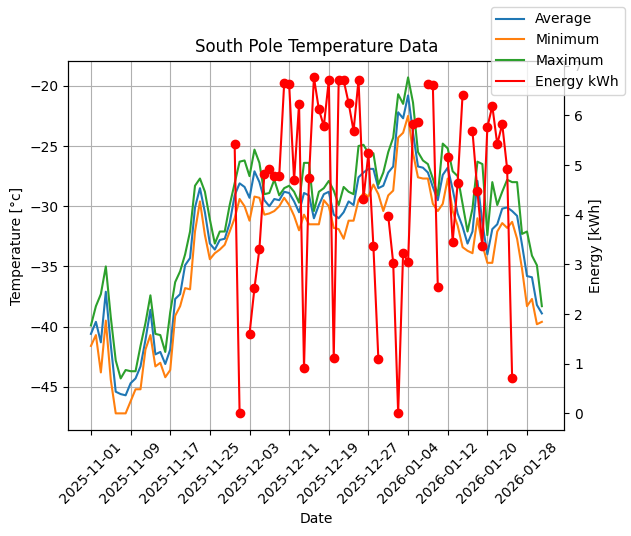

In [212]:
fig, ax1 = plt.subplots()
ax1.plot(FullDateRange, NovDecJanAvg, label = 'Average')
ax1.plot(FullDateRange, NovDecJanMin, label = 'Minimum')
ax1.plot(FullDateRange, NovDecJanMax, label = 'Maximum')
ax2 = ax1.twinx()
ax2.scatter(FullDateRange, IntegratedPower_101_kwh_alldata, color = 'red')
ax2.plot(FullDateRange, IntegratedPower_101_kwh_alldata, label = 'Energy kWh', color = 'red')
fig.legend()

tick_positions = range(0, len(FullDateRange), 8)
tick_labels = FullDateRange[::8]
ax1.set_xticks(tick_positions)
ax1.set_xticklabels(tick_labels, rotation = 45)
ax2.set_ylabel('Energy [kWh]')
ax1.set_xlabel('Date')
ax1.set_ylabel('Temperature [°c]')
ax1.set_title('South Pole Temperature Data')
ax1.grid('on')
plt.show()

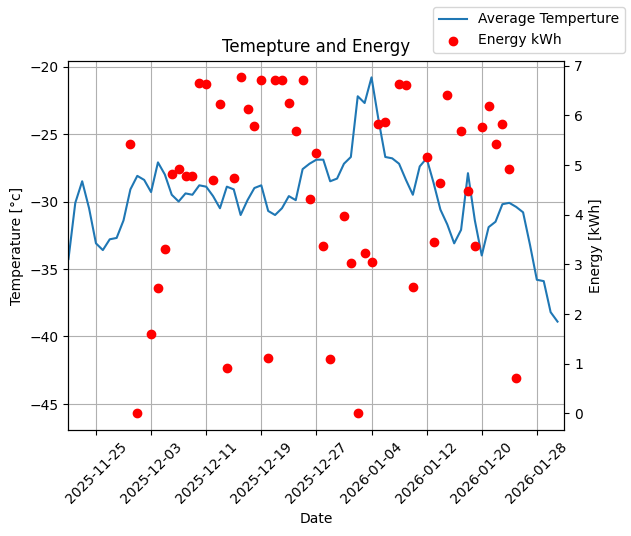

In [225]:
fig, ax1 = plt.subplots()
ax1.plot(FullDateRange, NovDecJanAvg, label = 'Average Temperture')
# ax1.plot(FullDateRange, NovDecJanMin, label = 'Minimum')
# ax1.plot(FullDateRange, NovDecJanMax, label = 'Maximum')
ax2 = ax1.twinx()
# ax2.scatter(FullDateRange, IntegratedPower_101_kwh_alldata, color = 'red')
ax2.scatter(FullDateRange, IntegratedPower_101_kwh_alldata, label = 'Energy kWh', color = 'red')
fig.legend()
tick_positions = range(0, len(FullDateRange), 8)
tick_labels = FullDateRange[::8]
ax1.set_xticks(tick_positions)
ax1.set_xticklabels(tick_labels, rotation = 45)
ax2.set_ylabel('Energy [kWh]')
ax1.set_xlabel('Date')
ax1.set_ylabel('Temperature [°c]')
ax1.set_title('Temepture and Energy')
ax1.grid('on')
ax1.set_xlim(20,92)
plt.show()

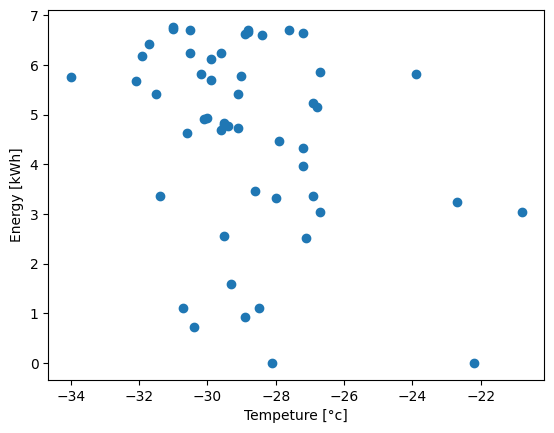

In [224]:
plt.scatter(NovDecJanAvg,IntegratedPower_101_kwh_alldata)
plt.xlabel('Tempeture [°c]')
plt.ylabel('Energy [kWh]')
plt.show()